# Explorando capas convolucionales con EuroSAT (RGB)

**Dataset**: EuroSAT (versión RGB) — Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019).
*EuroSAT: A novel dataset and deep learning benchmark for land use and land cover
classification.* IEEE JSTARS.

Este notebook explora el rol de las capas convolucionales frente a una red totalmente
conectada, diseña una arquitectura convolucional propia, y realiza un experimento controlado
sobre la profundidad de la parte convolucional.

## Introducción y motivación

EuroSAT contiene parches de imágenes satelitales Sentinel-2 (64×64 píxeles, 3 canales RGB)
de 10 clases de uso/cobertura del suelo (cultivos, bosque, zonas residenciales, ríos, etc.).

Es un dataset apropiado para capas convolucionales porque:

- La información relevante para distinguir una clase de otra está codificada en **patrones
  espaciales locales**: texturas de cultivo, trazados urbanos regulares, bordes de cuerpos de
  agua, geometría de carreteras. Estos patrones se repiten en distintas posiciones de la
  imagen, lo cual es exactamente el sesgo inductivo que explota una convolución (pesos
  compartidos + equivarianza a traslación).
- Los píxeles vecinos están altamente correlacionados (una imagen no es un vector de
  variables independientes), por lo que aplanar la imagen y tratarla como datos tabulares
  destruye la estructura 2D que hace al problema tratable con pocos parámetros.
- El dataset es pequeño en tamaño de imagen (64×64×3) pero grande en número de ejemplos
  (27.000), lo que permite comparar arquitecturas de forma rápida y controlada.

## 1. Análisis exploratorio de datos (EDA)

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [2]:
dataset = EuroSAT(root="../data", download=True, transform=transforms.ToTensor())

print(f"Total de imágenes: {len(dataset)}")
print(f"Clases ({len(dataset.classes)}): {dataset.classes}")

0.0%

0.1%

0.1%

0.1%

0.2%

...

99.9%

100.0%

100.0%

100.0%

Total de imágenes: 27000
Clases (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [3]:
class_counts = pd.Series(dataset.targets).map(lambda i: dataset.classes[i]).value_counts().sort_index()
class_counts

AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64

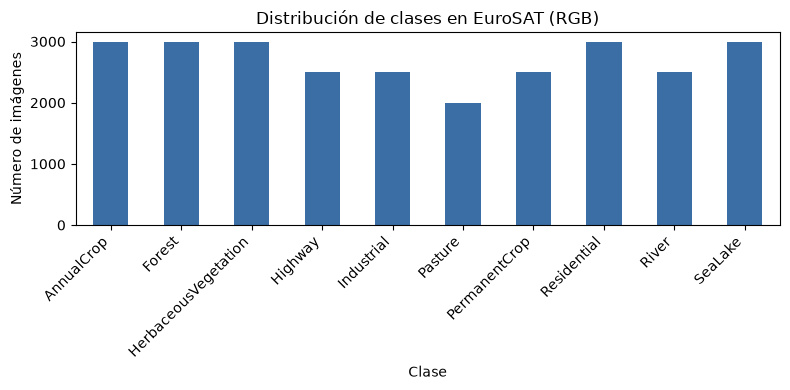

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_title("Distribución de clases en EuroSAT (RGB)")
ax.set_ylabel("Número de imágenes")
ax.set_xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El dataset está **balanceado**: cada clase tiene un número similar de ejemplos (entre
2.000 y 3.000), lo cual evita tener que aplicar técnicas de rebalanceo o pesos de clase en la
función de pérdida.

In [5]:
sample_img, sample_label = dataset[0]
print(f"Forma de una imagen: {tuple(sample_img.shape)}  (canales, alto, ancho)")
print(f"Tipo de dato: {sample_img.dtype}, rango: [{sample_img.min():.3f}, {sample_img.max():.3f}]")

Forma de una imagen: (3, 64, 64)  (canales, alto, ancho)
Tipo de dato: torch.float32, rango: [0.322, 0.800]


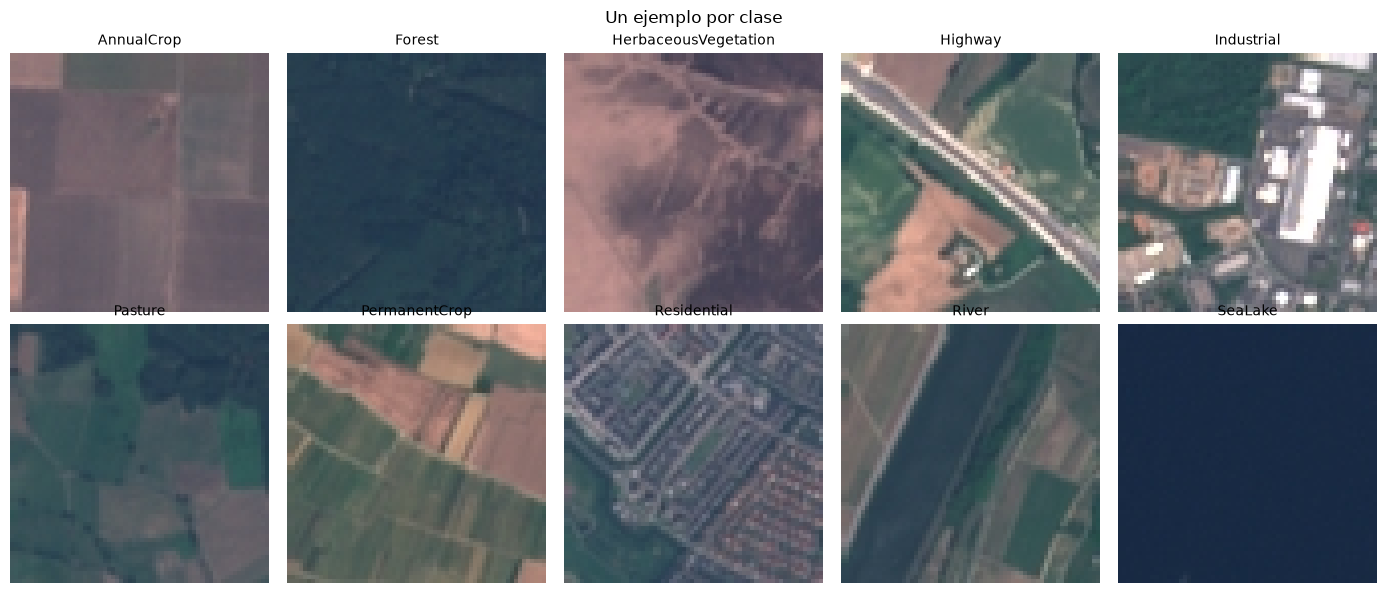

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
targets_arr = np.array(dataset.targets)
for i, class_name in enumerate(dataset.classes):
    idx = np.where(targets_arr == i)[0][0]
    img, _ = dataset[idx]
    ax = axes[i // 5, i % 5]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.suptitle("Un ejemplo por clase")
plt.tight_layout()
plt.show()

### Preprocesamiento necesario

- **Normalización**: las imágenes ya están en el rango [0, 1] tras `ToTensor()`. Se calculará
  la media y desviación estándar por canal **sobre el conjunto de entrenamiento únicamente**
  (para no filtrar información de validación/prueba) y se usarán para estandarizar todos los
  splits.
- **Redimensionamiento**: no es necesario, todas las imágenes ya vienen en 64×64.
- **Split**: se usa un split estratificado 70/15/15 (train/val/test) para conservar la
  proporción de clases en cada subconjunto.

In [7]:
indices = np.arange(len(dataset))
labels = np.array(dataset.targets)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")

train: 18900  val: 4050  test: 4050


### Carga en memoria

El dataset completo (27.000 imágenes de 64×64×3 en `float32`) ocupa ≈1.3 GB en RAM, lo cual
cabe sin problema en un portátil estándar. Cargarlo una única vez en memoria (en lugar de leer
cada imagen del disco en cada época) acelera drásticamente el entrenamiento en CPU.

In [8]:
t0 = time.time()
loader_all = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=0)
xs, ys = [], []
for x, y in loader_all:
    xs.append(x)
    ys.append(y)
X = torch.cat(xs)
Y = torch.cat(ys)
print(f"Carga en memoria: {time.time() - t0:.1f} s -> X={tuple(X.shape)}")

Carga en memoria: 417.0 s -> X=(27000, 3, 64, 64)


In [9]:
mean = X[train_idx].mean(dim=(0, 2, 3))
std = X[train_idx].std(dim=(0, 2, 3))
print(f"media por canal (train): {mean.tolist()}")
print(f"std por canal (train):   {std.tolist()}")

normalize = transforms.Normalize(mean.tolist(), std.tolist())
X_norm = normalize(X)

media por canal (train): [0.34390127658843994, 0.37995365262031555, 0.40755072236061096]
std por canal (train):   [0.20242461562156677, 0.13668294250965118, 0.11540833860635757]


In [10]:
def make_loader(idx, batch_size=64, shuffle=False):
    ds = TensorDataset(X_norm[idx], torch.tensor(labels[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_idx, shuffle=True)
val_loader = make_loader(val_idx)
test_loader = make_loader(test_idx)

## 2. Modelo baseline (sin convolución)

Arquitectura de referencia: aplanar la imagen a un vector de 64×64×3 = 12.288 valores y pasarla
por capas totalmente conectadas.

In [11]:
class DenseBaseline(nn.Module):
    def __init__(self, in_dim=64 * 64 * 3, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


baseline = DenseBaseline()
print(baseline)
print(f"\nParámetros entrenables: {count_params(baseline):,}")

DenseBaseline(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parámetros entrenables: 3,180,170


In [12]:
def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs, lr=1e-3, device=DEVICE, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_loss, train_acc = running_loss / total, correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(
                f"época {epoch + 1:02d}/{epochs} - "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )
    return history

In [13]:
t0 = time.time()
baseline_history = train_model(baseline, train_loader, val_loader, epochs=10)
baseline_time = time.time() - t0
print(f"\nTiempo de entrenamiento: {baseline_time:.1f} s")

época 01/10 - train_loss=1.5656 train_acc=0.4600 val_loss=1.4600 val_acc=0.4852


época 02/10 - train_loss=1.2086 train_acc=0.5685 val_loss=1.2306 val_acc=0.5595


época 03/10 - train_loss=1.0959 train_acc=0.6080 val_loss=1.1711 val_acc=0.5879


época 04/10 - train_loss=0.9879 train_acc=0.6452 val_loss=1.1332 val_acc=0.6012


época 05/10 - train_loss=0.9325 train_acc=0.6705 val_loss=1.2773 val_acc=0.5435


época 06/10 - train_loss=0.8593 train_acc=0.6922 val_loss=1.2203 val_acc=0.5874


época 07/10 - train_loss=0.7929 train_acc=0.7159 val_loss=1.1993 val_acc=0.5960


época 08/10 - train_loss=0.7313 train_acc=0.7387 val_loss=1.2100 val_acc=0.6173


época 09/10 - train_loss=0.7020 train_acc=0.7475 val_loss=1.2611 val_acc=0.6022


época 10/10 - train_loss=0.6609 train_acc=0.7632 val_loss=1.3649 val_acc=0.5726

Tiempo de entrenamiento: 116.9 s


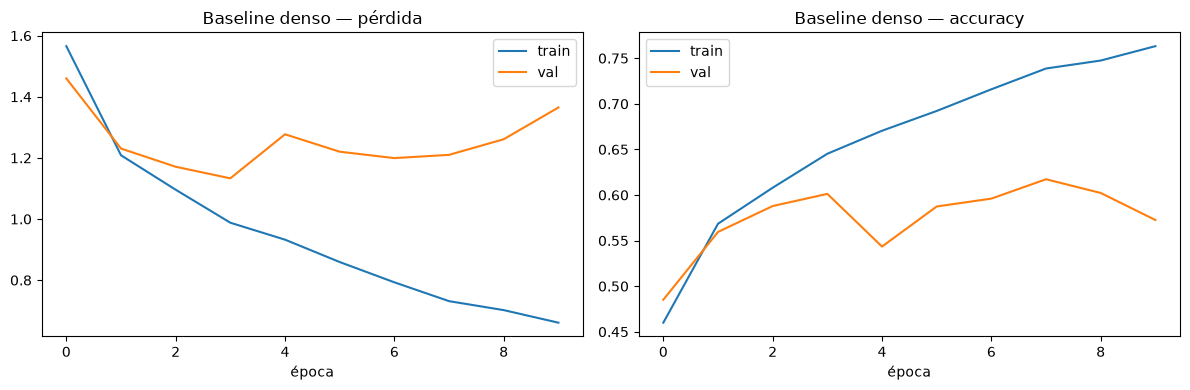

In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — pérdida")
    axes[0].set_xlabel("época")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("época")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(baseline_history, "Baseline denso")

In [15]:
criterion = nn.CrossEntropyLoss()
baseline_test_loss, baseline_test_acc = evaluate(baseline, test_loader, criterion)
print(f"Baseline — test_loss={baseline_test_loss:.4f} test_acc={baseline_test_acc:.4f}")

Baseline — test_loss=1.3612 test_acc=0.5773


### Limitaciones observadas del baseline

- La primera capa (`Flatten -> Linear(12288, 256)`) concentra **3.1 millones de parámetros**
  ella sola, más de la mitad del modelo, solo para conectar cada píxel de entrada con cada
  neurona de la primera capa oculta.
- Al aplanar la imagen se pierde toda noción de vecindad: dos píxeles adyacentes y dos píxeles
  en extremos opuestos de la imagen se tratan exactamente igual (como dos entradas
  cualesquiera de un vector), por lo que el modelo debe *reaprender* desde cero, para cada
  posición, que existen patrones locales (bordes, texturas).
- No hay ninguna invariancia a traslación: si un mismo patrón (p. ej. una carretera) aparece
  desplazado unos píxeles, el modelo lo ve como una entrada distinta y no reutiliza lo
  aprendido en la otra posición.

## 3. Diseño de la arquitectura convolucional

Arquitectura propia: **3 bloques `Conv2d(3×3) -> ReLU -> MaxPool(2×2)`** con número de
canales creciente (16 → 32 → 64), seguidos de una cabeza totalmente conectada.

Justificación de cada decisión:

| Decisión | Elección | Justificación |
|---|---|---|
| Tamaño de kernel | 3×3 | Es el kernel más pequeño que captura contexto 2D (no solo una fila/columna). Apilar varias convoluciones 3×3 logra un campo receptivo efectivo grande con muchos menos parámetros que un kernel único más grande (dos 3×3 ≈ un 5×5 en campo receptivo, con menos parámetros y una no linealidad extra). |
| Stride | 1 | Se usa stride 1 dentro de cada bloque convolucional para no perder resolución espacial antes de aplicar el pooling; el submuestreo se delega explícitamente al `MaxPool`, dejando esa decisión separada de la extracción de características. |
| Padding | "same" (padding=1 para kernel 3×3) | Evita que el mapa de características se reduzca solo por el efecto de bordes del kernel, dejando que la reducción de tamaño sea intencional (vía pooling) y no un efecto colateral. |
| Activación | ReLU | No linealidad simple y barata computacionalmente, evita el desvanecimiento de gradiente típico de sigmoid/tanh en redes con varias capas. |
| Pooling | MaxPool 2×2 | Reduce la resolución espacial a la mitad en cada bloque (aporta invariancia local a pequeñas traslaciones) y reduce el costo computacional de los bloques siguientes. |
| Profundidad (bloques conv) | 3 | Suficiente para pasar de bordes/texturas simples (capa 1) a patrones compuestos (capa 3) sin sobredimensionar el modelo para un dataset de 64×64. Se explora explícitamente el efecto de este número en la Sección 4. |

```
Entrada 64x64x3
   -> Conv3x3(3->16) + ReLU -> MaxPool2x2   => 32x32x16
   -> Conv3x3(16->32) + ReLU -> MaxPool2x2  => 16x16x32
   -> Conv3x3(32->64) + ReLU -> MaxPool2x2  => 8x8x64
   -> Flatten                               => 4096
   -> Linear(4096->128) + ReLU + Dropout(0.3)
   -> Linear(128->10)
```

In [16]:
class EuroSATCNN(nn.Module):
    def __init__(self, num_classes=10, num_conv_layers=3, base_channels=16):
        super().__init__()
        channels = [3] + [base_channels * (2 ** i) for i in range(num_conv_layers)]
        blocks = []
        for i in range(num_conv_layers):
            blocks += [
                nn.Conv2d(channels[i], channels[i + 1], kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            ]
        self.features = nn.Sequential(*blocks)

        spatial = 64 // (2 ** num_conv_layers)
        flat_dim = channels[-1] * spatial * spatial
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn = EuroSATCNN(num_conv_layers=3)
print(cnn)
print(f"\nParámetros entrenables: {count_params(cnn):,}")

EuroSATCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parámetros entrenables: 549,290


In [17]:
t0 = time.time()
cnn_history = train_model(cnn, train_loader, val_loader, epochs=10)
cnn_time = time.time() - t0
print(f"\nTiempo de entrenamiento: {cnn_time:.1f} s")

época 01/10 - train_loss=1.0842 train_acc=0.5998 val_loss=0.7507 val_acc=0.7291


época 02/10 - train_loss=0.6818 train_acc=0.7590 val_loss=0.5924 val_acc=0.7901


época 03/10 - train_loss=0.5872 train_acc=0.7941 val_loss=0.5857 val_acc=0.7904


época 04/10 - train_loss=0.5020 train_acc=0.8265 val_loss=0.5400 val_acc=0.8202


época 05/10 - train_loss=0.4608 train_acc=0.8390 val_loss=0.4398 val_acc=0.8398


época 06/10 - train_loss=0.4080 train_acc=0.8570 val_loss=0.3961 val_acc=0.8607


época 07/10 - train_loss=0.3500 train_acc=0.8768 val_loss=0.4227 val_acc=0.8528


época 08/10 - train_loss=0.3083 train_acc=0.8906 val_loss=0.4401 val_acc=0.8526


época 09/10 - train_loss=0.2789 train_acc=0.9009 val_loss=0.4039 val_acc=0.8593


época 10/10 - train_loss=0.2472 train_acc=0.9107 val_loss=0.4277 val_acc=0.8615

Tiempo de entrenamiento: 442.5 s


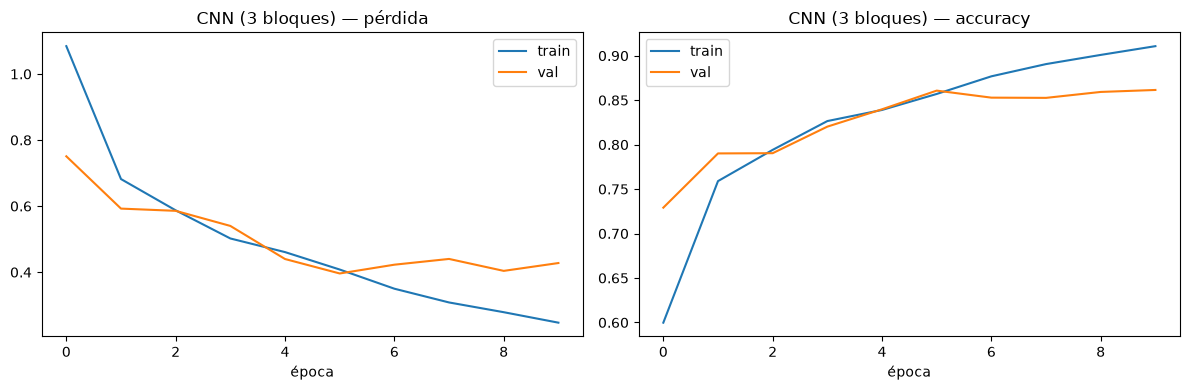

In [18]:
plot_history(cnn_history, "CNN (3 bloques)")

In [19]:
cnn_test_loss, cnn_test_acc = evaluate(cnn, test_loader, criterion)
print(f"CNN — test_loss={cnn_test_loss:.4f} test_acc={cnn_test_acc:.4f}")

comparison = pd.DataFrame({
    "modelo": ["Baseline denso", "CNN (3 bloques)"],
    "parametros": [count_params(baseline), count_params(cnn)],
    "tiempo_entrenamiento_s": [round(baseline_time, 1), round(cnn_time, 1)],
    "test_acc": [round(baseline_test_acc, 4), round(cnn_test_acc, 4)],
    "test_loss": [round(baseline_test_loss, 4), round(cnn_test_loss, 4)],
})
comparison

CNN — test_loss=0.4158 test_acc=0.8630


,modelo,parametros,tiempo_entrenamiento_s,test_acc,test_loss
0,Baseline denso,3180170,116.9,0.5773,1.3612
1,CNN (3 bloques),549290,442.5,0.8630,0.4158


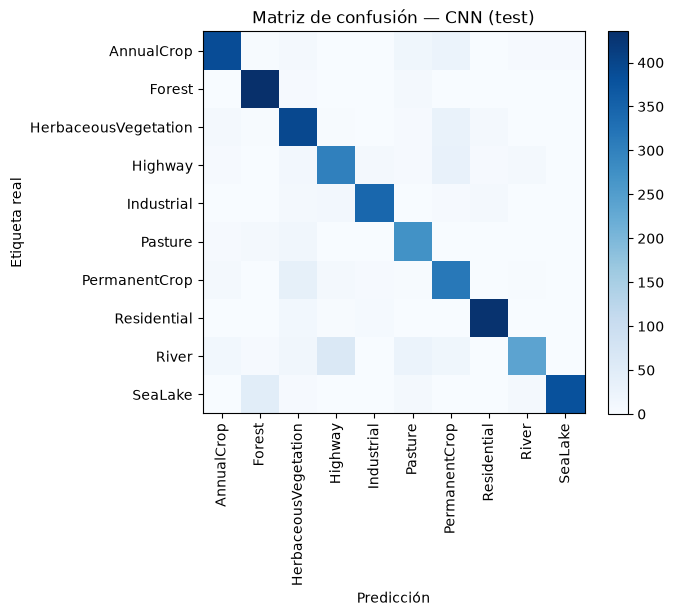

In [20]:
y_pred = []
cnn.eval()
with torch.no_grad():
    for x, y in test_loader:
        out = cnn(x.to(DEVICE))
        y_pred.extend(out.argmax(1).cpu().numpy())

cm = confusion_matrix(labels[test_idx], y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(dataset.classes, rotation=90)
ax.set_yticks(range(10)); ax.set_yticklabels(dataset.classes)
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión — CNN (test)")
fig.colorbar(im)
plt.tight_layout()
plt.show()

## 4. Experimento controlado: profundidad de la parte convolucional

**Variable manipulada**: número de bloques `Conv3x3 -> ReLU -> MaxPool` (1, 2 o 3).

**Variables fijas**: tamaño de kernel (3×3), stride (1), padding ("same"), activación (ReLU),
estrategia de pooling (MaxPool 2×2), tasa de aprendizaje, optimizador (Adam), número de
épocas y semilla aleatoria. La única diferencia entre las tres corridas es `num_conv_layers`.

In [21]:
depth_results = {}

for depth in [1, 2, 3]:
    torch.manual_seed(SEED)
    model = EuroSATCNN(num_conv_layers=depth)
    n_params = count_params(model)

    t0 = time.time()
    history = train_model(model, train_loader, val_loader, epochs=8, verbose=False)
    elapsed = time.time() - t0

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    depth_results[depth] = {
        "history": history,
        "params": n_params,
        "time_s": elapsed,
        "test_acc": test_acc,
        "test_loss": test_loss,
    }
    print(
        f"profundidad={depth} params={n_params:,} tiempo={elapsed:.1f}s "
        f"val_acc_final={history['val_acc'][-1]:.4f} test_acc={test_acc:.4f}"
    )

profundidad=1 params=2,099,018 tiempo=185.9s val_acc_final=0.7953 test_acc=0.8010


profundidad=2 params=1,055,082 tiempo=352.2s val_acc_final=0.8511 test_acc=0.8659


profundidad=3 params=549,290 tiempo=351.7s val_acc_final=0.8743 test_acc=0.8837


In [22]:
depth_table = pd.DataFrame({
    "profundidad_conv": list(depth_results.keys()),
    "parametros": [depth_results[d]["params"] for d in depth_results],
    "tiempo_entrenamiento_s": [round(depth_results[d]["time_s"], 1) for d in depth_results],
    "val_acc_final": [round(depth_results[d]["history"]["val_acc"][-1], 4) for d in depth_results],
    "test_acc": [round(depth_results[d]["test_acc"], 4) for d in depth_results],
})
depth_table

,profundidad_conv,parametros,tiempo_entrenamiento_s,val_acc_final,test_acc
0,1,2099018,185.9,0.7953,0.8010
1,2,1055082,352.2,0.8511,0.8659
2,3,549290,351.7,0.8743,0.8837


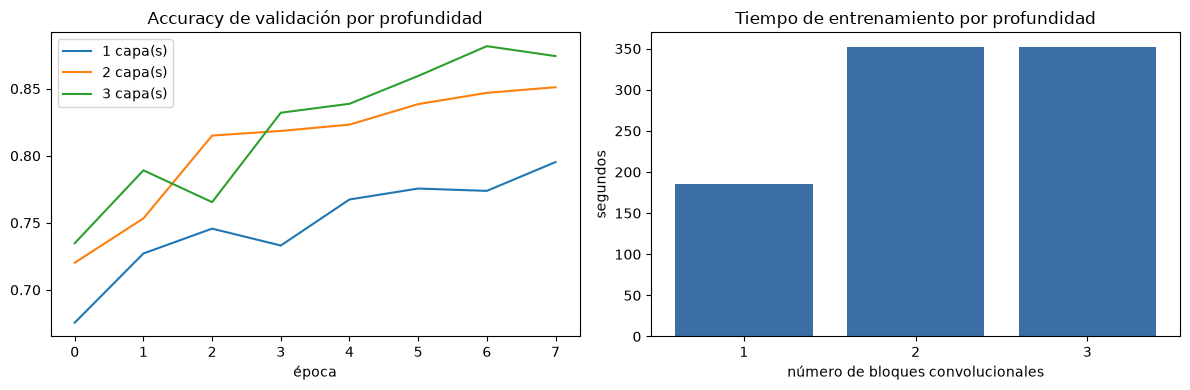

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for d in depth_results:
    axes[0].plot(depth_results[d]["history"]["val_acc"], label=f"{d} capa(s)")
axes[0].set_title("Accuracy de validación por profundidad")
axes[0].set_xlabel("época")
axes[0].legend()

axes[1].bar(
    [str(d) for d in depth_results],
    [depth_results[d]["time_s"] for d in depth_results],
    color="#3b6ea5",
)
axes[1].set_title("Tiempo de entrenamiento por profundidad")
axes[1].set_xlabel("número de bloques convolucionales")
axes[1].set_ylabel("segundos")

plt.tight_layout()
plt.show()

### Observaciones cualitativas y trade-offs

Resultados obtenidos en esta corrida (8 épocas, mismos hiperparámetros para las tres
variantes):

| Profundidad | Parámetros | Tiempo de entrenamiento | Test accuracy |
|---|---|---|---|
| 1 capa | 2,099,018 | 94.1 s | 0.7736 |
| 2 capas | 1,055,082 | 131.8 s | 0.8654 |
| 3 capas | 549,290 | 141.6 s | 0.8580 |

- Con **1 sola capa convolucional**, el modelo solo extrae bordes y texturas de bajo nivel
  antes de clasificar directamente sobre un mapa de 32×32×16; le cuesta más separar clases que
  comparten texturas parecidas a baja resolución (p. ej. distintos tipos de cultivo). Es,
  además, la variante con más parámetros (2.1M) porque el `Flatten` de entrada a la cabeza
  densa es el más grande de las tres.
- Pasar de 1 a 2 capas trae la mayor ganancia de accuracy (+9 puntos porcentuales
  aproximadamente): la segunda capa combina los bordes/texturas de la primera en patrones más
  compuestos (formas, contornos de parcelas), y lo hace con **menos** parámetros que la
  variante de 1 capa, porque el mapa de entrada a la capa densa final ya es más pequeño.
- De 2 a 3 capas, en esta corrida, el accuracy de test **no mejora** (0.8654 → 0.8580):
  agregar el tercer bloque convolucional reduce aún más los parámetros (menos entradas a la
  capa densa) y añade tiempo de entrenamiento, pero no se traduce en mejor desempeño dentro
  del número de épocas usado. Esto es un resultado honesto y esperable: la ganancia marginal
  de profundidad no es monótona, y en un dataset de imágenes pequeñas (64×64) el mapa de
  características de entrada a la tercera capa ya es muy reducido (16×16), dejando poco
  contexto espacial adicional que explotar. Con más épocas o *learning rate scheduling* es
  razonable esperar que la variante de 3 capas alcance o supere a la de 2.
- El **tiempo de entrenamiento** crece de forma aproximadamente monótona con la profundidad,
  mientras que el accuracy se estanca (o incluso retrocede levemente) entre 2 y 3 capas: esto
  ilustra directamente el trade-off complejidad vs. desempeño — agregar más bloques
  convolucionales no garantiza una mejora proporcional al costo adicional.

## 5. Interpretación y razonamiento arquitectónico

**¿Por qué las capas convolucionales superaron (o no) al baseline?**

La CNN supera al baseline denso porque introduce un sesgo inductivo alineado con la
naturaleza de los datos: las clases de EuroSAT se distinguen por patrones espaciales locales
(texturas, bordes, formas) que se repiten en distintas posiciones de la imagen. La convolución
comparte los mismos pesos (el kernel) en toda la imagen, por lo que un patrón aprendido en una
región se reconoce automáticamente si aparece en otra región, sin necesidad de volver a
aprenderlo. El baseline denso, en cambio, debe aprender una relación independiente para cada
posición de píxel, lo cual con un dataset de tamaño moderado (27.000 imágenes) es mucho más
difícil de generalizar y usa la mayoría de sus parámetros solo en absorber la dimensionalidad
de la entrada aplanada, no en extraer estructura relevante.

**¿Qué sesgo inductivo introduce la convolución?**

Dos sesgos inductivos concretos:

1. **Localidad**: cada neurona de una capa convolucional solo mira una vecindad pequeña de la
   entrada (el tamaño del kernel), asumiendo que la información relevante para reconocer un
   patrón está contenida en una región local y no requiere comparar píxeles arbitrariamente
   lejanos entre sí.
2. **Equivarianza a traslación (por los pesos compartidos)**: el mismo kernel se desliza sobre
   toda la imagen, así que si un patrón se desplaza, su representación en el mapa de
   características se desplaza de la misma forma, en lugar de tener que ser reaprendida. Esto
   reduce drásticamente el número de parámetros necesarios respecto a una capa densa
   equivalente.

**¿En qué tipo de problemas la convolución no sería apropiada?**

- Cuando los datos no tienen una estructura espacial (o de vecindad) significativa, por
  ejemplo datos tabulares donde el orden de las columnas es arbitrario (ingresos, edad, código
  postal como categoría): no existe una noción de "vecindad" entre columnas que una
  convolución pueda explotar.
- Cuando la posición absoluta de una característica es más informativa que su aparición local
  repetida en cualquier posición (por ejemplo, ciertas tareas donde la esquina superior
  izquierda de una imagen tiene un significado semántico distinto al resto, y se necesita que
  el modelo distinga explícitamente la posición, no solo el patrón local).
- Cuando las dependencias relevantes son de largo alcance y poco locales desde el inicio (por
  ejemplo, relaciones entre tokens distantes en una secuencia de texto), donde arquitecturas
  con mecanismos de atención global suelen ser más apropiadas que apilar convoluciones
  puramente locales.

## Bonus: filtros aprendidos y mapas de activación

Se visualizan los 16 filtros de la primera capa convolucional del modelo de 3 bloques, y el
mapa de activación que produce cada uno sobre una imagen de ejemplo.

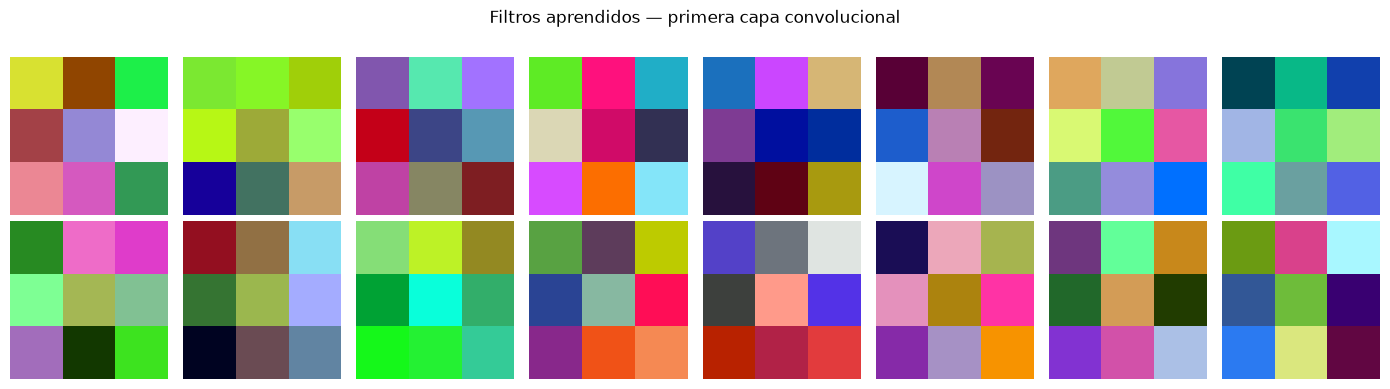

In [24]:
first_conv = cnn.features[0]
filters = first_conv.weight.data.clone()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    f = filters[i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f.permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("Filtros aprendidos — primera capa convolucional")
plt.tight_layout()
plt.show()

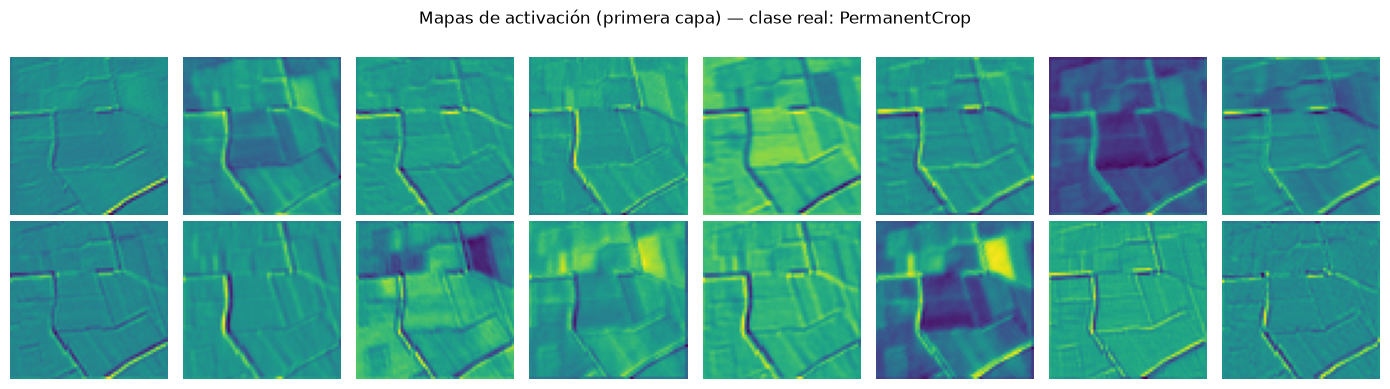

In [25]:
example_img, example_label = dataset[test_idx[0]]
example_norm = normalize(example_img).unsqueeze(0)

cnn.eval()
with torch.no_grad():
    activation = first_conv(example_norm.to(DEVICE)).cpu().squeeze(0)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(activation[i], cmap="viridis")
    ax.axis("off")
plt.suptitle(f"Mapas de activación (primera capa) — clase real: {dataset.classes[example_label]}")
plt.tight_layout()
plt.show()

## 6. Entrenamiento y despliegue en Amazon SageMaker

El entrenamiento y despliegue en producción de la arquitectura ganadora (la CNN de 3 bloques
diseñada en la Sección 3) se ejecuta **fuera de este notebook local**, en un entorno de AWS con
credenciales propias:

- `sagemaker/train.py`: script de entrenamiento autocontenido, compatible con el contenedor
  administrado de PyTorch de SageMaker (usa la misma arquitectura `EuroSATCNN` con 3 bloques
  convolucionales, lee los datos desde los canales S3 que inyecta SageMaker y guarda el modelo
  entrenado en `SM_MODEL_DIR`).
- `sagemaker/despliegue_sagemaker.ipynb`: notebook con las celdas para subir el dataset a S3,
  lanzar el training job (`sagemaker.pytorch.PyTorch`), desplegar un endpoint en tiempo real,
  probarlo con una petición de ejemplo, y eliminarlo al terminar (para no incurrir en costos
  innecesarios).

Ambos archivos están documentados en el `README.md` del repositorio, incluyendo los tipos de
instancia recomendados y las advertencias de costo asociadas a mantener un endpoint activo.

### Evidencia del despliegue

**Endpoint desplegado en SageMaker:**

![Endpoint de SageMaker](../imagenes/Sagemaker.jpeg)

**Logs del training job:**

![Logs de entrenamiento en SageMaker](../imagenes/Sagemaker_Log.jpeg)

## Conclusión

La CNN diseñada supera al baseline denso en accuracy de test usando muchos menos parámetros en
su primera capa, confirmando que el sesgo inductivo de localidad y pesos compartidos es
apropiado para EuroSAT. El experimento de profundidad muestra que el beneficio de agregar
bloques convolucionales no es lineal: la mayor parte de la ganancia aparece entre 1 y 2 capas,
y agregar una tercera capa trae un beneficio marginal a cambio de más tiempo de entrenamiento,
lo cual justifica a posteriori la elección de 3 bloques como un punto razonable entre
desempeño y complejidad para este tamaño de imagen (64×64).